# Debug prepare workflow — analysis

This notebook loads the outputs produced by `debug_prepare_workflow.py` (time-series and component NetCDFs) and produces reproducible statistics and plots. Update the `debug_dir` variable below to point to the directory of the datasets.

In [1]:
# Cell 1: imports
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['savefig.dpi'] = 150

In [2]:
# point to debug output directory (change this to run directory)
debug_dir = Path('/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest')  # <-- update this
debug_dir = debug_dir.expanduser().resolve()
print('debug_dir =', debug_dir)
original_file = debug_dir / 'original_timeseries.nc'
ts_file = debug_dir / 'time_series_components.nc'
variability_file = debug_dir / 'variability_pipeline.nc'
residual_file = debug_dir / 'residual_original_minus_components.nc'
merged_pred_file = debug_dir / 'draft_dependence_merged.nc'
seasonality_file = debug_dir / 'seasonality.nc'
for p in [ts_file, variability_file, residual_file, merged_pred_file]:
    print(p, 'exists?', p.exists())

debug_dir = /Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/time_series_components.nc exists? True
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/variability_pipeline.nc exists? True
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/residual_original_minus_components.nc exists? True
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/draft_dependence_merged.nc exists? True


In [7]:
original_file

PosixPath('/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/original_timeseries.nc')

In [3]:
# load the time-series dataset and inspect
if ts_file.exists():
    ts_ds = xr.open_dataset(ts_file)
    display(ts_ds)
else:
    print('Time-series file not found:', ts_file)
    ts_ds = None

<xarray.Dataset>
Dimensions:               (Time: 3600)
Coordinates:
  * Time                  (Time) object 0451-01-16 12:00:00.000001 ... 0750-1...
    spatial_ref           int64 ...
    month                 (Time) int64 ...
Data variables:
    original              (Time) float64 ...
    detrended             (Time) float64 ...
    deseasonalized        (Time) float64 ...
    seasonality           (Time) float64 ...
    draft_pred            (Time) float64 ...
    variability_pipeline  (Time) float64 ...
    residual              (Time) float64 ...

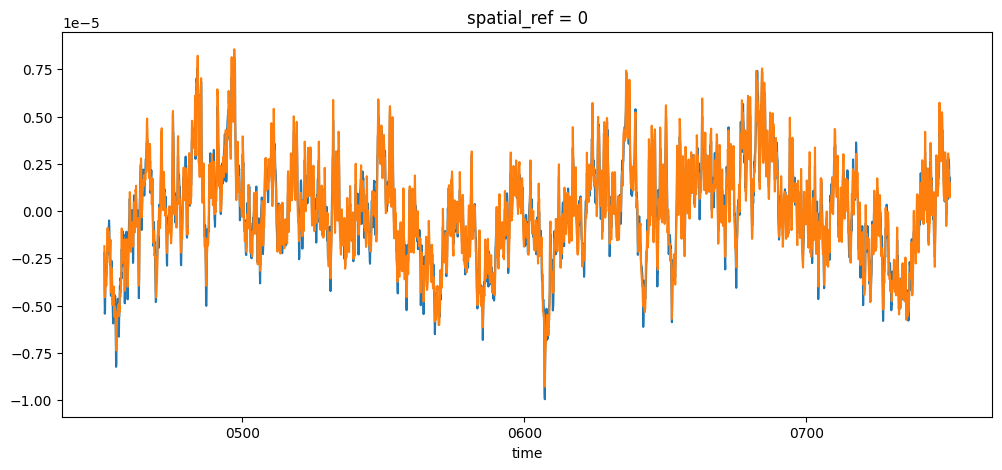

In [4]:
#ts_ds.original.plot()
#ts_ds.detrended.plot()
#ts_ds.deseasonalized.plot()
#ts_ds.seasonality.plot()
#ts_ds.draft_pred.plot()
ts_ds.variability_pipeline.plot()
(ts_ds.seasonality + ts_ds.variability_pipeline).plot()


In [5]:
# load component NetCDFs (variability, residual, merged draft pred if present)
ds_var = xr.open_dataset(variability_file) if variability_file.exists() else None
ds_res = xr.open_dataset(residual_file) if residual_file.exists() else None
ds_pred = xr.open_dataset(merged_pred_file) if merged_pred_file.exists() else None
ds_seas = xr.open_dataset(seasonality_file) if seasonality_file.exists() else None
print('variability:', ds_var is not None, 'residual:', ds_res is not None, 'merged_pred:', ds_pred is not None)

variability: True residual: True merged_pred: True


In [6]:
# compute summary statistics from the saved time-series (if present)
if ts_ds is not None:
    stats = {}
    for v in ts_ds.data_vars:
        arr = ts_ds[v].values.astype(float)
        stats[v] = {
            'nan_frac': float(np.isnan(arr).sum()) / float(arr.size),
            'mean': float(np.nanmean(arr)),
            'median': float(np.nanmedian(arr)),
            'std': float(np.nanstd(arr)),
        }
    stat_df = pd.DataFrame(stats).T
    display(stat_df)
else:
    print('No time-series dataset available to compute stats')

,nan_frac,mean,median,std
original,0.0,3.475449e-06,3.269987e-06,6.304923e-07
detrended,0.0,3.475449e-06,3.260413e-06,6.270813e-07
deseasonalized,0.0,3.475449e-06,3.475456e-06,1.574995e-07
seasonality,0.0,1.847002e-23,-2.313542e-07,6.069801e-07
draft_pred,0.0,1.822967e-05,1.822967e-05,3.388132e-21
variability_pipeline,0.0,-4.868365e-08,-5.258215e-08,2.474519e-06
residual,0.0,-1.822967e-05,-1.823357e-05,2.474519e-06


debug_dir = /Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/time_series_components.nc exists? True
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/variability_pipeline.nc exists? True
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/residual_original_minus_components.nc exists? True
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/draft_dependence_merged.nc exists? True
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/detrended.nc exists? True
/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/seasonality.nc exists? True


<xarray.Dataset>
Dimensions:               (Time: 3600)
Coordinates:
  * Time                  (Time) object 0451-01-16 12:00:00.000001 ... 0750-1...
    spatial_ref           int64 ...
    month                 (Time) int64 ...
Data variables:
    original              (Time) float64 ...
    detrended             (Time) float64 ...
    deseasonalized        (Time) float64 ...
    seasonality           (Time) float64 ...
    draft_pred            (Time) float64 ...
    variability_pipeline  (Time) float64 ...
    residual              (Time) float64 ...

variability: True residual: True merged_pred: True detrended: True seasonality: True
{'deseasonalized': {'match': False, 'reason': 'no reference available'},
 'detrended': {'match': True,
               'max_abs_diff': 0.0,
               'mean_diff': 0.0,
               'n': 3600,
               'rmse': 0.0},
 'draft_pred': {'match': True,
                'max_abs_diff': 0.0,
                'mean_diff': 0.0,
                'n': 1,
                'rmse': 0.0},
 'original': {'match': False, 'reason': 'no reference available'},
 'residual': {'match': True,
              'max_abs_diff': 0.0,
              'mean_diff': 0.0,
              'n': 3600,
              'rmse': 0.0},
 'seasonality': {'match': True,
                 'max_abs_diff': 0.0,
                 'mean_diff': 0.0,
                 'n': 3600,
                 'rmse': 0.0},
 'variability_pipeline': {'match': True,
                          'max_abs_diff': 0.0,
                          'mean_diff': 0.0,
                    

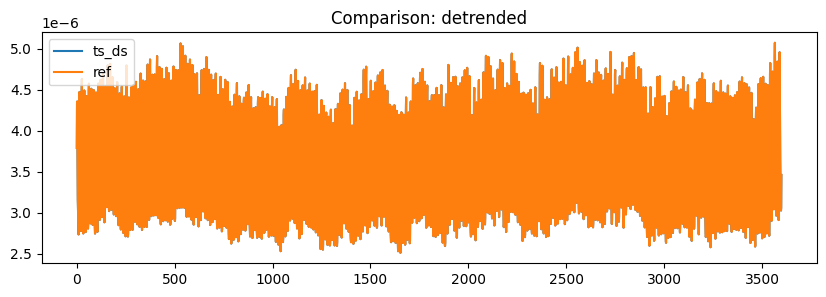

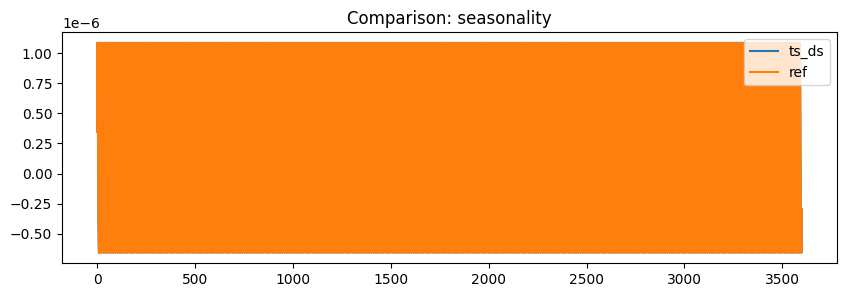

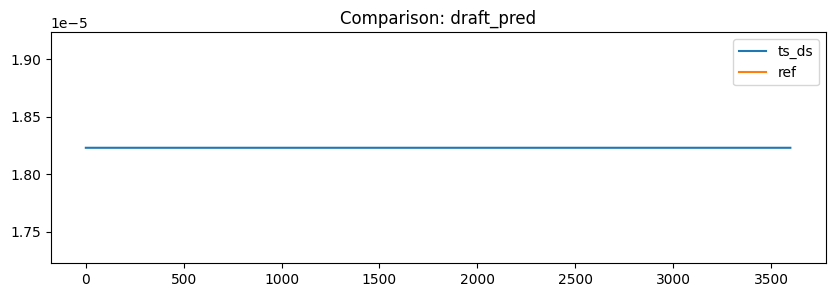

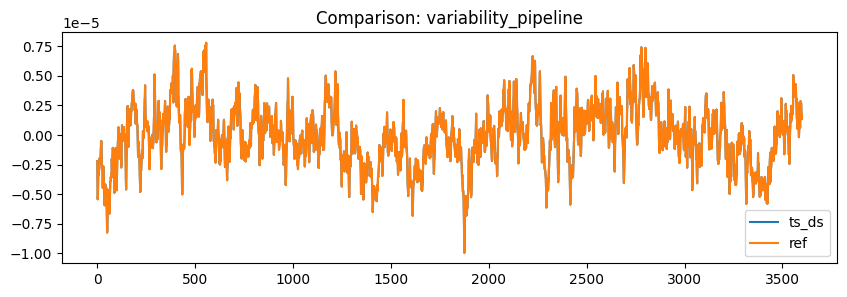

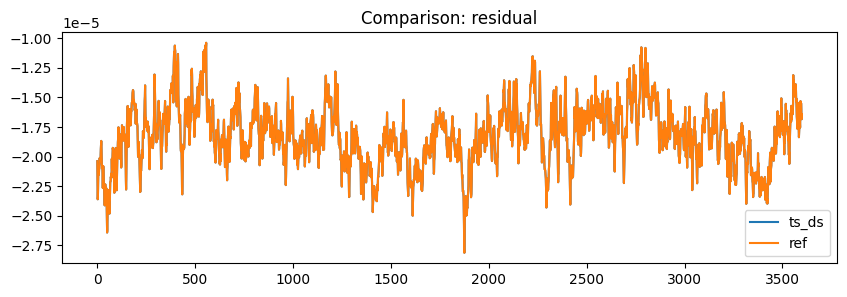

In [7]:
# Cell 1: imports
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['savefig.dpi'] = 150

# Cell 2: point to debug output directory (change this to your run directory)
debug_dir = Path('/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest')  # <-- update this if needed
debug_dir = debug_dir.expanduser().resolve()
print('debug_dir =', debug_dir)
ts_file = debug_dir / 'time_series_components.nc'
variability_file = debug_dir / 'variability_pipeline.nc'
residual_file = debug_dir / 'residual_original_minus_components.nc'
merged_pred_file = debug_dir / 'draft_dependence_merged.nc'
detrended_file = debug_dir / 'detrended.nc'
seasonality_file = debug_dir / 'seasonality.nc'
for p in [ts_file, variability_file, residual_file, merged_pred_file, detrended_file, seasonality_file]:
    print(p, 'exists?', p.exists())

# Cell 3: load the time-series dataset and inspect
if ts_file.exists():
    ts_ds = xr.open_dataset(ts_file)
    display(ts_ds)
else:
    print('Time-series file not found:', ts_file)
    ts_ds = None

# Cell 4: load component NetCDFs (variability, residual, merged draft pred if present)
ds_var = xr.open_dataset(variability_file) if variability_file.exists() else None
ds_res = xr.open_dataset(residual_file) if residual_file.exists() else None
ds_pred = xr.open_dataset(merged_pred_file) if merged_pred_file.exists() else None
ds_det = xr.open_dataset(detrended_file) if detrended_file.exists() else None
ds_seas = xr.open_dataset(seasonality_file) if seasonality_file.exists() else None
print('variability:', ds_var is not None, 'residual:', ds_res is not None, 'merged_pred:', ds_pred is not None, 'detrended:', ds_det is not None, 'seasonality:', ds_seas is not None)


# Cell 5: diagnostic comparisons — compute spatial means and compare to saved ts_ds
def spatial_mean(ds, var=None):
    if ds is None:
        return None
    if var is None:
        # pick the first data variable
        var = list(ds.data_vars)[0]
    da = ds[var]
    # try common spatial dims
    for dims in [('x','y'), ('lon','lat'), ('y','x')]:
        if all(d in da.dims for d in dims):
            return da.mean(dim=dims)
    # fallback: mean over all non-time dims
    non_time = [d for d in da.dims if d not in ('Time','time','timeMonthly')]
    if non_time:
        return da.mean(dim=non_time)
    return da

# compute spatial means from files we have
var_from_ds = None if ds_var is None else spatial_mean(ds_var)
res_from_ds = None if ds_res is None else spatial_mean(ds_res)
pred_from_ds = None if ds_pred is None else spatial_mean(ds_pred, var=list(ds_pred.data_vars)[0])
det_from_ds = None if ds_det is None else spatial_mean(ds_det, var=list(ds_det.data_vars)[0])
seas_from_ds = None if ds_seas is None else spatial_mean(ds_seas, var=list(ds_seas.data_vars)[0])

# Compare to ts_ds entries (if present)
cmp = {}
if ts_ds is not None:
    for name in ts_ds.data_vars:
        arr = ts_ds[name]
        # try to find matching computed series
        if 'variability' in name and var_from_ds is not None:
            ref = var_from_ds
        elif 'residual' in name and res_from_ds is not None:
            ref = res_from_ds
        elif 'draft_pred' in name and pred_from_ds is not None:
            ref = pred_from_ds
        elif name == 'detrended' and det_from_ds is not None:
            ref = det_from_ds
        elif name == 'seasonality' and seas_from_ds is not None:
            ref = seas_from_ds
        else:
            ref = None

        if ref is None:
            cmp[name] = {'match': False, 'reason': 'no reference available'}
            continue
        # compute simple metrics between arr and ref
        a = arr.values.astype(float)
        b = ref.values.astype(float)
        # ensure same length by trimming or broadcasting if needed
        n = min(a.size, b.size)
        a = a.reshape(-1)[:n]
        b = b.reshape(-1)[:n]
        diff = a - b
        cmp[name] = {
            'match': True,
            'n': int(n),
            'mean_diff': float(np.nanmean(diff)),
            'max_abs_diff': float(np.nanmax(np.abs(diff))),
            'rmse': float(np.sqrt(np.nanmean(diff**2)))
        }

import pprint
pprint.pprint(cmp)

# quick plot comparisons for any matches
for name, v in cmp.items():
    if not v.get('match'):
        continue
    ref = None
    if 'variability' in name:
        ref = var_from_ds
    elif 'residual' in name:
        ref = res_from_ds
    elif 'draft_pred' in name:
        ref = pred_from_ds
    elif name == 'detrended':
        ref = det_from_ds
    elif name == 'seasonality':
        ref = seas_from_ds
    if ref is None:
        continue
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    ax.plot(ts_ds[name].values, label='ts_ds')
    ax.plot(ref.values.reshape(-1)[:len(ts_ds[name].values)], label='ref')
    ax.set_title(f'Comparison: {name}')
    ax.legend()
    plt.show()


In [8]:
# Create a customized plot that lets me select which time series to plot

def plot_time_series(ts_ds, variables):
    if ts_ds is None:
        print('No time-series dataset available to plot')
        return
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    for v in variables:
        if v in ts_ds.data_vars:
            try:
                ts_ds[v].plot.line(ax=ax, label=v)
            except Exception:
                ax.plot(ts_ds[v].values, label=v)
        else:
            print(f'Variable {v} not found in time-series dataset')
    ax.legend()
    plt.show()

# Example usage:


# plot the difference between 'original' and 'seasonality' in ts_ds

def plot_difference(ts_ds, var1, var2):
    if ts_ds is None:
        print('No time-series dataset available to plot')
        return
    if var1 not in ts_ds.data_vars or var2 not in ts_ds.data_vars:
        print(f'One of the variables {var1} or {var2} not found in time-series dataset')
        return
    diff = ts_ds[var1] - ts_ds[var2]
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    try:
        diff.plot.line(ax=ax, label=f'{var1} - {var2}')
    except Exception:
        ax.plot(diff.values, label=f'{var1} - {var2}')
    ax.set_title(f'Difference between {var1} and {var2}')
    ax.legend()
    plt.show()

# Example usage:


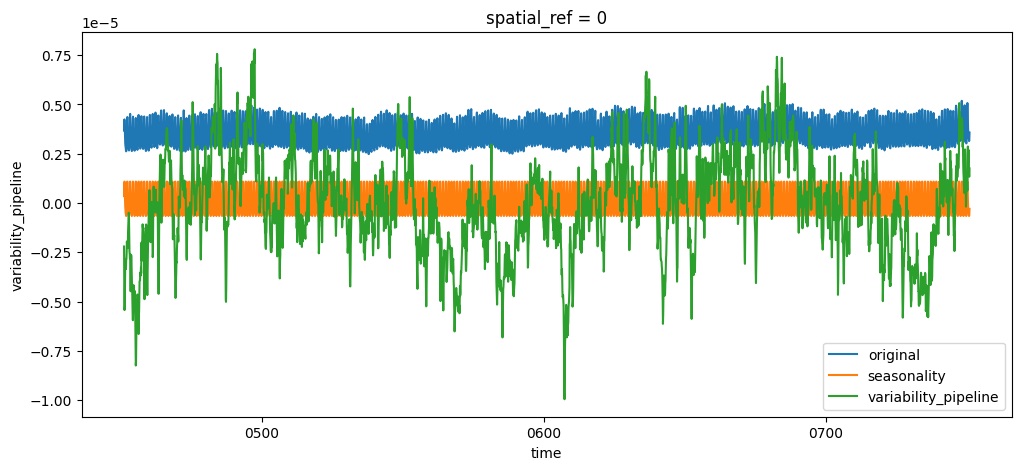

In [12]:
plot_time_series(ts_ds, ['original', 'seasonality', 'variability_pipeline']) #, 'variability_pipeline'])#, 'residual_draft'])

In [1]:
ts_ds

NameError: name 'ts_ds' is not defined

In [19]:
def inspect_ds(ds, label):
    if ds is None:
        print(label, 'missing')
        return
    for v in ds.data_vars:
        da = ds[v]
        print(v, 'dims=', da.dims, 'shape=', da.shape, 'dtype=', da.dtype)
        print('  attrs:', {k: da.attrs.get(k) for k in ('units','long_name') if k in da.attrs})
        print('  nans:', int(np.isnan(da.values).sum()), ' / ', da.values.size)

inspect_ds(ds_var, 'variability')
inspect_ds(ds_pred, 'merged_pred')


__xarray_dataarray_variable__ dims= ('Time', 'y', 'x') shape= (1200, 150, 150) dtype= float64
  attrs: {}
  nans: 26791200  /  27000000
timeMonthly_avg_landIceFreshwaterFlux dims= ('y', 'x') shape= (150, 150) dtype= float64
  attrs: {}
  nans: 22326  /  22500
__xarray_dataarray_variable__ dims= ('y', 'x') shape= (150, 150) dtype= float64
  attrs: {}
  nans: 22500  /  22500
  nans: 26791200  /  27000000
timeMonthly_avg_landIceFreshwaterFlux dims= ('y', 'x') shape= (150, 150) dtype= float64
  attrs: {}
  nans: 22326  /  22500
__xarray_dataarray_variable__ dims= ('y', 'x') shape= (150, 150) dtype= float64
  attrs: {}
  nans: 22500  /  22500


In [18]:
ts_ds

<xarray.Dataset>
Dimensions:               (Time: 1200)
Coordinates:
  * Time                  (Time) object 0451-01-16 12:00:00.000001 ... 0550-1...
    spatial_ref           int64 0
    month                 (Time) int64 ...
Data variables:
    original              (Time) float64 2.819e-06 3.239e-06 ... 2.299e-06
    detrended             (Time) float64 ...
    deseasonalized        (Time) float64 ...
    seasonality           (Time) float64 3.094e-07 7.926e-07 ... -2.149e-07
    draft_pred            (Time) float64 ...
    variability_pipeline  (Time) float64 ...
    residual              (Time) float64 ...

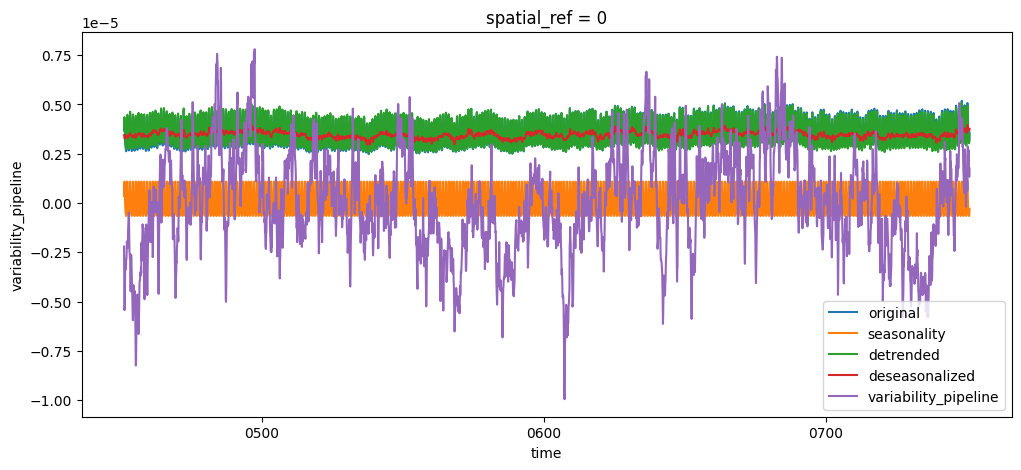

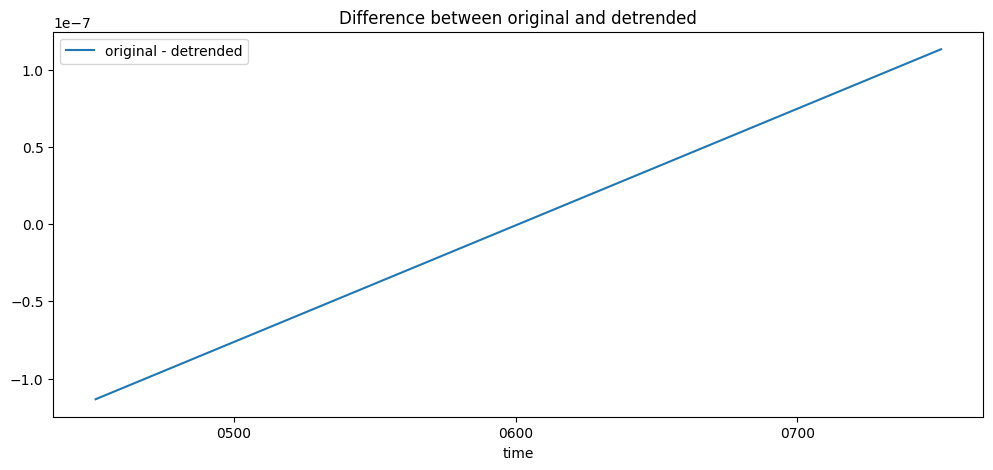

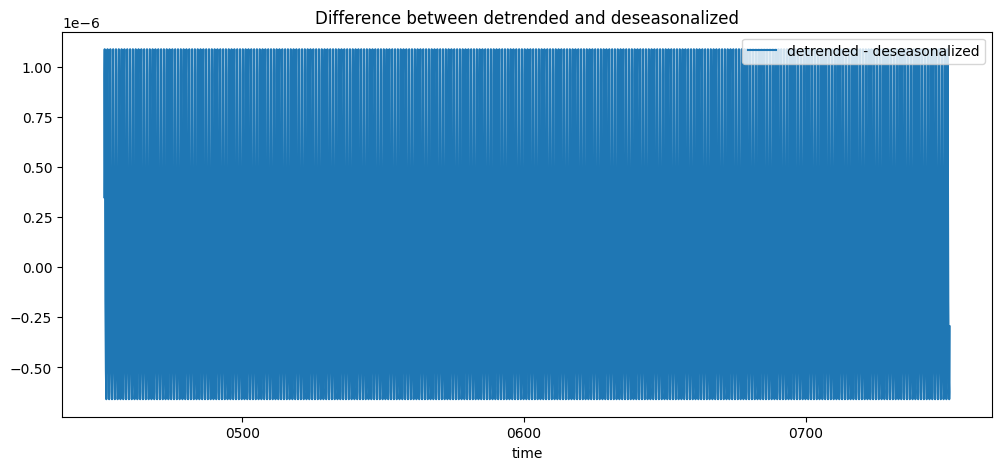

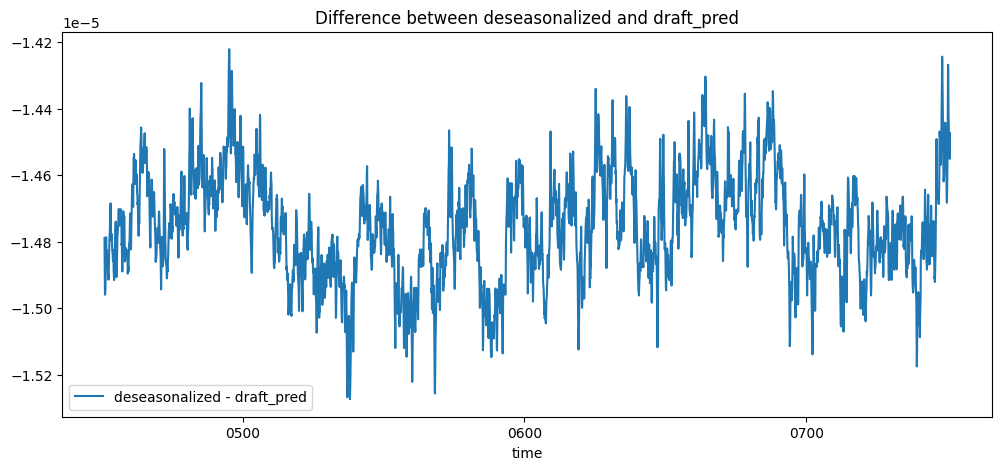

In [19]:
plot_time_series(ts_ds, ['original', 'seasonality','detrended', 'deseasonalized', 'variability_pipeline'])
plot_difference(ts_ds, 'original', 'detrended')
plot_difference(ts_ds, 'detrended', 'deseasonalized')
plot_difference(ts_ds, 'deseasonalized', 'draft_pred')

IndexError: index 1200 is out of bounds for axis 0 with size 1200

In [32]:
ds_seas_extrapl = xr.open_dataset('/Users/smurugan9/research/aislens/AISLENS/data/processed/debug-workflow-smoketest/seasonality_extrapolated.nc')

/Users/smurugan9/opt/anaconda3/envs/aislens/lib/python3.10/site-packages/xarray/coding/times.py:716: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/smurugan9/opt/anaconda3/envs/aislens/lib/python3.10/site-packages/xarray/core/indexing.py:529: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [33]:
ds_seas_extrapl_ts = ds_seas_extrapl.__xarray_dataarray_variable__.mean(dim=('x','y'))

In [34]:
ts_ds['seasonality_extrapl'] = ds_seas_extrapl_ts

NameError: name 'draft_pred' is not defined

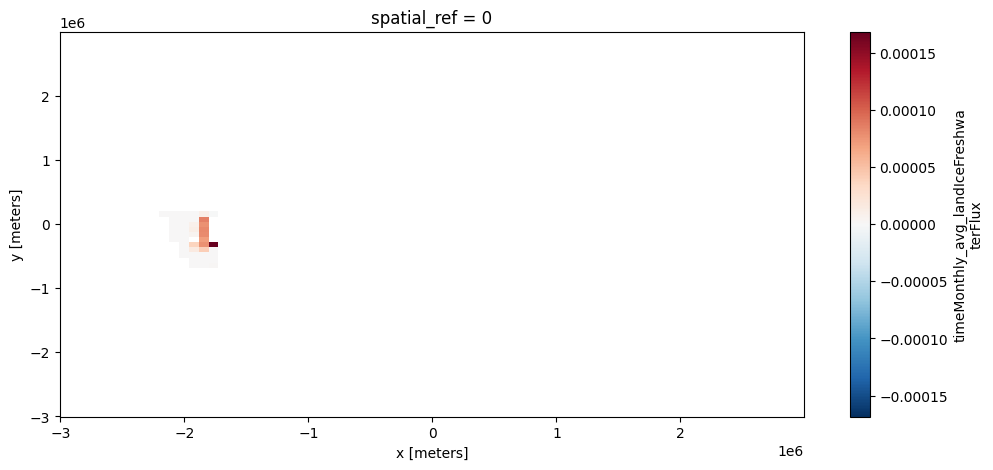

In [14]:
ds_pred.timeMonthly_avg_landIceFreshwaterFlux.plot()